<a href="https://colab.research.google.com/github/GDVevo/ml_uni/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%965_%D0%9B%D0%B8%D0%BD%D0%B5%D0%B9%D0%BD%D0%B0%D1%8F_%D0%B8_%D0%BB%D0%BE%D0%B3%D0%B8%D1%81%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%81%D0%B8%D1%8F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **Практическая работа №5. Линейная и логистическая регрессия**



## **Линейная регрессия**



### **Задание №1. Прогнозирование продаж автомобилей**

- **Шаг 1**: Загрузите набор данных о продажах автомобилей, содержащий информацию о цене, возрасте, пробеге и других характеристиках.
  - **Совет №1**: Проверьте данные на наличие пропущенных значений и выбросов. Используйте `pandas` для обнаружения пропусков (`df.isnull().sum()`) и выбросов (например, с помощью метода межквартильного размаха - `df.boxplot()`).
  - **Совет №2**: Для пропущенных значений используйте стратегию заполнения средними значениями или медианой, чтобы минимизировать влияние на распределение данных (`df.fillna()`).




- Ссылка на набор данных: https://www.kaggle.com/datasets/gagandeep16/car-sales

In [31]:
# Ваш код
import pandas as pd
import kagglehub
kagglehub.dataset_download("gagandeep16/car-sales")

Using Colab cache for faster access to the 'car-sales' dataset.


'/kaggle/input/car-sales'

Manufacturer            0
Model                   0
Sales_in_thousands      0
__year_resale_value    36
Vehicle_type            0
Price_in_thousands      2
Engine_size             1
Horsepower              1
Wheelbase               1
Width                   1
Length                  1
Curb_weight             2
Fuel_capacity           1
Fuel_efficiency         3
Latest_Launch           0
Power_perf_factor       2
dtype: int64


<Axes: >

,Sales_in_thousands,__year_resale_value,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,...,Model_Town car,Model_V40,Model_V70,Model_Villager,Model_Viper,Model_Voyager,Model_Windstar,Model_Wrangler,Model_Xterra,Vehicle_type_Passenger
0,16.919,16.360,21.500000,1.8,140.0,101.2,67.3,172.4,2.639,13.2,...,False,False,False,False,False,False,False,False,False,True
1,39.384,19.875,28.400000,3.2,225.0,108.1,70.3,192.9,3.517,17.2,...,False,False,False,False,False,False,False,False,False,True
2,14.114,18.225,27.390755,3.2,225.0,106.9,70.6,192.0,3.470,17.2,...,False,False,False,False,False,False,False,False,False,True
3,8.588,29.725,42.000000,3.5,210.0,114.6,71.4,196.6,3.850,18.0,...,False,False,False,False,False,False,False,False,False,True
4,20.397,22.255,23.990000,1.8,150.0,102.6,68.2,178.0,2.998,16.4,...,False,False,False,False,False,False,False,False,False,True


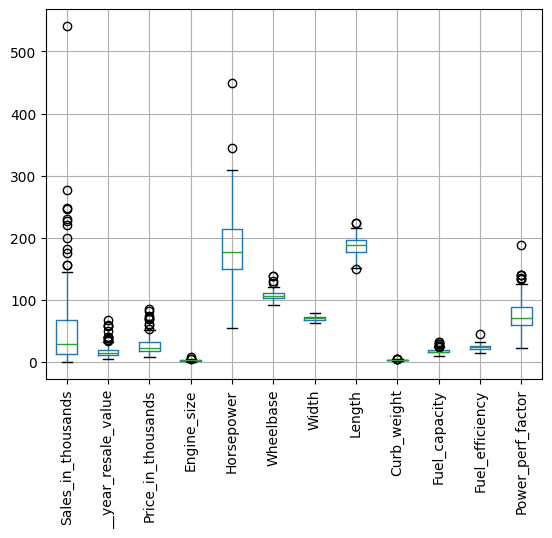

In [32]:
df = pd.read_csv('/kaggle/input/car-sales/Car_sales.csv') # если вывел ошибку, запустить еще раз

print(df.isnull().sum())
display(df.boxplot(rot=90))
df2 = pd.get_dummies(df, columns=['Manufacturer', 'Latest_Launch', 'Model', 'Vehicle_type'], drop_first=True)

df2.fillna(df2.mean(), inplace=True)

df2.head()

- **Шаг 2**: Проведите предварительный анализ данных:
  - Постройте гистограммы для каждого числового признака, чтобы понять их распределение.
  - Постройте диаграммы рассеяния для выявления зависимостей между признаками и целевой переменной (ценой).
  - **Совет**: Используйте корреляционную матрицу для выявления сильных линейных зависимостей между признаками.

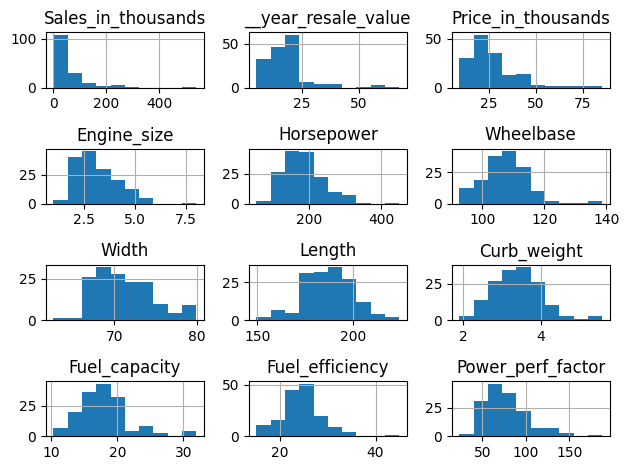

In [33]:
# Ваш код
import matplotlib.pyplot as plt

df2.hist()
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:896: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best")
/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:896: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best")
/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:896: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best")
/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:896: UserWarning: No artists with labels found to put in legend.  Note that artists whose label sta

IndexError: index 3 is out of bounds for axis 0 with size 3

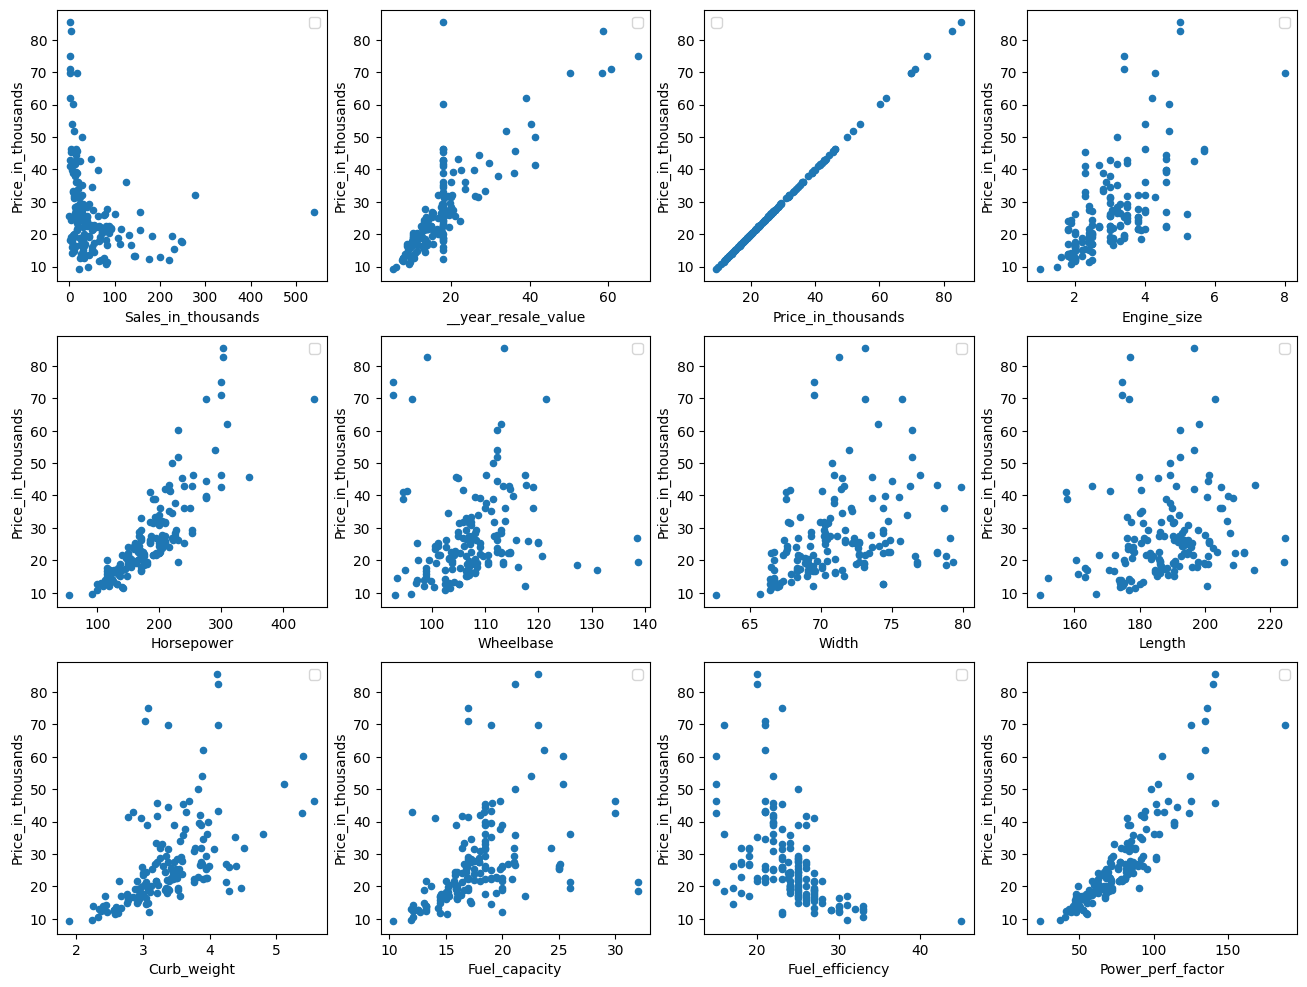

In [34]:
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(16, 12))
for idx, feature in enumerate(df2.columns[:-1]):
     df2.plot(feature, "Price_in_thousands", subplots=True, kind="scatter", ax=axes[idx // 4, idx % 4])

- **Шаг 3**: Разделите данные на обучающую и тестовую выборки (например, 70% на обучение и 30% на тестирование) с помощью `train_test_split` из `sklearn.model_selection`.

In [35]:
# Ваш код
from sklearn.model_selection import train_test_split
X = df2.drop('Price_in_thousands', axis=1)
y = df2['Price_in_thousands']

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    random_state=42)
display(X_train.shape, X_test.shape)

(109, 325)

(48, 325)

- **Шаг 4**: Постройте и обучите модели линейной регрессии с различными типами регуляризации:
  - Обучите базовую модель `LinearRegression` (без регуляризации).
  - Обучите модель **Ridge** (L2-регуляризация) с подбором гиперпараметра `alpha` с помощью `GridSearchCV`.
  - Обучите модель **Lasso** (L1-регуляризация) с подбором гиперпараметра `alpha` с помощью `RandomizedSearchCV`.
  - Обучите модель **ElasticNet** (комбинация L1 и L2) с подбором гиперпараметров `alpha` и `l1_ratio` с помощью `GridSearchCV` и/или `RandomizedSearchCV`.
  - **Совет**: Используйте `np.logspace(-4, 4, 50)` для генерации сетки значений `alpha`.



In [39]:
# Ваш код
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np

model = LinearRegression()
ridge = Ridge(random_state=42)
lasso = Lasso(random_state=42)
elnet = ElasticNet(random_state=42)

# Параметры L1/L2
param_dist = {'alpha':np.logspace(-4, 4, 50)}
# Параметры ElasticNet
param_dist_elnet = {'alpha':np.logspace(-4, 4, 50), 'l1_ratio':np.linspace(0.001, 0.99, 20)}

grid_search = GridSearchCV(ridge, param_dist, cv=5, n_jobs=-1)
grid_search.fit(X, y)

rsearch_lasso = RandomizedSearchCV(lasso, param_distributions=param_dist,
                                   cv=5, n_jobs=-1, random_state=42)
rsearch_lasso.fit(X, y)

grid_search_elnet = GridSearchCV(elnet, param_dist_elnet, cv=5, n_jobs=-1)
grid_search_elnet.fit(X, y)

models = {
    'Linear Regression (без регуляризации)': LinearRegression(),
    'Ridge (L2)': grid_search.best_estimator_,
    'Lasso (L1)': rsearch_lasso.best_estimator_,
    'ElasticNet (L1 + L2)': grid_search_elnet.best_estimator_
}

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.333e+01, tolerance: 3.172e+00
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.342e+01, tolerance: 3.172e+00
  model = cd_fast.enet_coordinate_descent(


- **Шаг 5**: Оцените качество всех моделей с использованием метрик MSE, RMSE, MAE и R².
  - Выведите значения метрик для каждой модели и интерпретируйте их.


In [40]:
# Ваш код
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

results = {}

# Обучение и оценка каждой модели
for name, model in models.items():
    model.fit(X_train, y_train)
    # Предсказание
    y_pred = model.predict(X_test)

    # Метрики
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Сохранение результатов
    results[name] = {
        'MSE': mse,
        'RMSE': rmse,
        'MAE':mae,
        'R²': r2,
    }

    print(f"\n{name}:")
    print(f"  MSE:  {mse:.4f}")
    print(f"  MSE:  {mse:.4f}")
    print(f"  MAE: {mae:.4f}")
    print(f"  R²:   {r2:.4f}")


Linear Regression (без регуляризации):
  MSE:  8.8630
  MSE:  8.8630
  MAE: 2.0399
  R²:   0.9691

Ridge (L2):
  MSE:  5.6537
  MSE:  5.6537
  MAE: 1.7006
  R²:   0.9803

Lasso (L1):
  MSE:  5.7785
  MSE:  5.7785
  MAE: 1.1550
  R²:   0.9798

ElasticNet (L1 + L2):
  MSE:  5.6103
  MSE:  5.6103
  MAE: 1.4076
  R²:   0.9804


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.304e+00, tolerance: 1.735e+00
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.173e+01, tolerance: 1.735e+00
  model = cd_fast.enet_coordinate_descent(


- **Шаг 6**: Визуализируйте результаты:
  - Постройте график зависимости предсказанных цен от фактических для каждой модели.



In [ ]:
# Ваш код



- **Шаг 7**: **Сравните все модели между собой по целевым метрикам (MSE, RMSE, MAE, R²)**:
  - Создайте сводную таблицу с метриками для всех моделей.
  - Определите лучшую модель и выведите для неё все метрики, а также оптимальные гиперпараметры.


In [ ]:
# Ваш код

---



### **Задание №2. Влияние погодных условий на урожайность**




- **Шаг 1**: Загрузите набор данных о погодных условиях и урожайности сельскохозяйственных культур.
  - **Совет**: Проверьте данные на наличие пропущенных значений и выбросов. Используйте стратегию заполнения пропусков средними значениями или медианой.

- Ссылка на набор данных: https://www.kaggle.com/datasets/waqi786/climate-change-impact-on-agriculture


In [ ]:
# Ваш код




- **Шаг 2**: Выполните анализ данных:
  - Постройте корреляционную матрицу для выявления зависимостей между признаками.
  - Постройте диаграммы рассеяния для ключевых признаков.
  - **Совет**: Удалите или преобразуйте признаки с низкой корреляцией с целевой переменной, чтобы улучшить модель.



In [ ]:
# Ваш код

- **Шаг 3**: Разделите данные на обучающую и тестовую выборки.

In [ ]:
# Ваш код



- **Шаг 4**: Постройте и обучите модели линейной регрессии с различными типами регуляризации для оценки влияния температуры и уровня осадков на урожайность:
  - Обучите базовую модель `LinearRegression` (без регуляризации).
  - Обучите модель **Ridge** (L2-регуляризация) с подбором гиперпараметра `alpha` с помощью `RandomizedSearchCV`.
  - Обучите модель **Lasso** (L1-регуляризация) с подбором гиперпараметра `alpha` с помощью `GridSearchCV`.
  - Обучите модель **ElasticNet** с подбором гиперпараметров `alpha` и `l1_ratio` с помощью `GridSearchCV` и/или `RandomizedSearchCV` .

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np

# Ваш код

- **Шаг 5**: Проведите оценку точности всех моделей.
  - Выведите значения метрик MSE, RMSE, MAE и R² для каждой модели и интерпретируйте их.

In [ ]:
# Ваш код



- **Шаг 6**: Визуализируйте данные и результаты моделей:
  - Постройте графики зависимости предсказанных значений от фактических для каждой модели.

In [ ]:
# Ваш код

- **Шаг 7**: **Сравните все модели между собой по целевым метрикам (MSE, RMSE, MAE, R²)**:
  - Создайте сводную таблицу с метриками для всех моделей.
  - Определите лучшую модель и выведите для неё все метрики, а также оптимальные гиперпараметры.

In [ ]:
# Ваш код

- **Шаг 8: Проанализируйте влияние признаков на урожайность**

  - На основе лучшей модели проведите анализ важности признаков:

    - Извлеките коэффициенты (`coef_`) лучшей модели и сопоставьте их с названиями признаков.
    - Визуализируйте важность признаков с помощью горизонтальной столбчатой диаграммы.
    - Проинтерпретируйте результаты: определите, какие погодные факторы (температура, осадки, CO₂ и др.) оказывают наибольшее положительное и отрицательное влияние на урожайность.
    - **Совет**: Для модели Lasso обратите внимание на признаки с нулевыми коэффициентами — они были исключены как незначимые.
    - **Совет**: Если данные были стандартизированы (`StandardScaler`), коэффициенты можно напрямую сравнивать по абсолютной величине для оценки относительной важности.



In [ ]:
# Ваш код

#### **Интерпретация результатов (пример формулировки для отчёта):**


**[ТРЕБУЕТСЯ ЗАПОЛНИТЬ!]**


> На основе анализа коэффициентов лучшей модели установлено, что:
> - **Положительное влияние** на урожайность оказывают: [перечислить признаки с положительными коэффициентами].
> - **Отрицательное влияние** на урожайность оказывают: [перечислить признаки с отрицательными коэффициентами].
> - Наиболее значимым фактором является [название признака] с коэффициентом [значение], что означает: при увеличении данного показателя на 1 единицу (при прочих равных) урожайность изменяется на [значение коэффициента] единиц.

---



## **Логистическая регрессия**



### **Задание №3. Классификация клиентов банка**

- **Шаг 1**: Загрузите набор данных о клиентах банка, включающий данные о возрасте, доходе, кредитной истории и других характеристиках.
  - **Совет**: Проверьте данные на наличие пропущенных значений и выбросов. Используйте стратегию заполнения пропусков средними значениями или медианой.



- Ссылка на набор данных: https://www.kaggle.com/datasets/henriqueyamahata/bank-marketing/data

In [ ]:
# Ваш код

- **Шаг 2**: Проведите анализ данных и предобработку:
  - Закодируйте категориальные переменные с помощью `OneHotEncoder` или `pd.get_dummies`.
  - Нормализуйте числовые признаки с помощью `StandardScaler` для улучшения обучения модели.
  - **Совет**: Убедитесь, что все признаки имеют одинаковый масштаб, чтобы избежать доминирования одного признака над другими.

In [ ]:
# Ваш код

- **Шаг 3**: Разделите данные на обучающую и тестовую выборки.

In [ ]:
# Ваш код

- **Шаг 4**: Постройте и обучите модели логистической регрессии с различными типами регуляризации для предсказания вероятности открытия депозитного счета клиентом:
  - Обучите модель `LogisticRegression` с **L2-регуляризацией** (`penalty='l2'`) и подбором гиперпараметра `C` с помощью `GridSearchCV`.
  - Обучите модель `LogisticRegression` с **L1-регуляризацией** (`penalty='l1'`, `solver='saga'`) и подбором гиперпараметра `C` с помощью `RandomizedSearchCV`.
  - Обучите модель `LogisticRegression` с **ElasticNet-регуляризацией** (`penalty='elasticnet'`, `solver='saga'`) и подбором гиперпараметров `C` и `l1_ratio` с помощью `GridSearchCV` и/или `RandomizedSearchCV` .
  - **Совет**: Для L1 и ElasticNet используйте `solver='saga'`, так как он поддерживает оба типа регуляризации.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np


# Ваш код


- **Шаг 5**: Оцените качество всех моделей с использованием метрик точности (Accuracy), полноты (Recall), точности (Precision) и F1-меры.
  - Выведите значения метрик для каждой модели и интерпретируйте их. Обратите внимание на баланс между точностью и полнотой.
  - Постройте матрицу ошибок для каждой модели с помощью `confusion_matrix` и визуализируйте их с помощью `seaborn.heatmap`.

In [ ]:
# Ваш код

- **Шаг 6**: Визуализируйте ROC-кривые для всех моделей и вычислите AUC для оценки.
  - Используйте `roc_curve` и `auc` из `sklearn.metrics` для построения и расчёта.
  - Постройте все ROC-кривые на одном графике для наглядного сравнения.



In [ ]:
# Ваш код

- **Шаг 7**: **Сравните все модели между собой по целевым метрикам (Accuracy, Precision, Recall, F1, AUC)**:
  - Создайте сводную таблицу с метриками для всех моделей.
  - Определите лучшую модель и выведите для неё все метрики, оптимальные гиперпараметры и матрицу ошибок.

In [ ]:
# Ваш код